# BUS 32120 (Winter 2026): Final Project Report

## 1. Project Introduction

### 1.1. Research Question
Imagine you are a gold investor. For predicting next-period gold direction, which is more reliable for you:
- index-only signals (UUP and VIX), or
- news-text signals (WSJ headlines)?

### 1.2. Business Motivation
This project is designed for gold investors who need a practical signal source.
The final goal is to compare Model A (index-only) and Model B (text-only) and explain when each source is more useful.

## 2. Data Pipeline: API + News + SQL

### 2.1. Imports

In [11]:
import re
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import yfinance as yf
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

import math

from scipy import stats

#nltk.download('stopwords', quiet=True)
#nltk.download('wordnet', quiet=True)
#nltk.download('omw-1.4', quiet=True)
#nltk.download('averaged_perceptron_tagger_eng', quiet=True)

### 2.2. Download Market Data from Yahoo Finance API
(GLD, UUP, VIX) and run basic data checks

In [5]:
# We use the lastest start date of the 3 datasets, i.e. 2007-03-01 as the start date for all sets.
START = '2007-03-01'
END ='2018-01-01'

gld_raw = yf.download('GLD', start=START, end=END, progress=False)
uup_raw = yf.download('UUP', start=START, end=END, progress=False)
vix_raw = yf.download('^VIX', start=START, end=END, progress=False)

print('GLD shape:', gld_raw.shape)
print('UUP shape:', uup_raw.shape)
print('VIX shape:', vix_raw.shape)

print()
print('GLD columns:', gld_raw.columns)
print('UUP columns:', uup_raw.columns)
print('VIX columns:', vix_raw.columns)

print(gld_raw.head())
print(uup_raw.head())
print(vix_raw.head())

GLD shape: (2730, 5)
UUP shape: (2730, 5)
VIX shape: (2730, 5)

GLD columns: MultiIndex([( 'Close', 'GLD'),
            (  'High', 'GLD'),
            (   'Low', 'GLD'),
            (  'Open', 'GLD'),
            ('Volume', 'GLD')],
           names=['Price', 'Ticker'])
UUP columns: MultiIndex([( 'Close', 'UUP'),
            (  'High', 'UUP'),
            (   'Low', 'UUP'),
            (  'Open', 'UUP'),
            ('Volume', 'UUP')],
           names=['Price', 'Ticker'])
VIX columns: MultiIndex([( 'Close', '^VIX'),
            (  'High', '^VIX'),
            (   'Low', '^VIX'),
            (  'Open', '^VIX'),
            ('Volume', '^VIX')],
           names=['Price', 'Ticker'])
Price           Close       High        Low       Open    Volume
Ticker            GLD        GLD        GLD        GLD       GLD
Date                                                            
2007-03-01  65.820000  66.750000  65.580002  66.230003   7108000
2007-03-02  63.709999  65.000000  63.340000  64.58

### 2.3. Clean API Data and Build Daily Market Table

Data cleaning:

In [6]:
# Check for missiing values:
print()
print('GLD missing values:')
print(gld_raw.isna().sum())
print()
print('UUP missing values:')
print(uup_raw.isna().sum())
print()
print('VIX missing values:')
print(vix_raw.isna().sum())

# Apart from NAs, we should also watch out for values <=0, as it is unlikely for indexes to be equal, or smaller than 0.
print('Number of duplicates in each dataset:')
print((gld_raw[("Close", "GLD")]<=0).sum())
print((uup_raw[("Close", "UUP")]<=0).sum())
print((vix_raw[("Close", "^VIX")]<=0).sum())

# We can also check for duplicates:
gld_raw=gld_raw.drop_duplicates()
uup_raw=uup_raw.drop_duplicates()
vix_raw=vix_raw.drop_duplicates()


GLD missing values:
Price   Ticker
Close   GLD       0
High    GLD       0
Low     GLD       0
Open    GLD       0
Volume  GLD       0
dtype: int64

UUP missing values:
Price   Ticker
Close   UUP       0
High    UUP       0
Low     UUP       0
Open    UUP       0
Volume  UUP       0
dtype: int64

VIX missing values:
Price   Ticker
Close   ^VIX      0
High    ^VIX      0
Low     ^VIX      0
Open    ^VIX      0
Volume  ^VIX      0
dtype: int64
Number of duplicates in each dataset:
0
0
0


We can see that there is no NAs in all datasets nor is there any abnormal values (<=0) in our interested columns. 
Then we rename the columns and join those 3 datasets together:

In [7]:
# Rename data columns:
gld_close = gld_raw[("Close", "GLD")].rename("gld_close").to_frame()
uup_close = uup_raw[("Close", "UUP")].rename("uup_close").to_frame()
vix_close = vix_raw[("Close", "^VIX")].rename("vix_close").to_frame()

# Join 3 datasets:
market_daily = (
    gld_close.join(uup_close, how='inner')
    .join(vix_close, how='inner')
    .reset_index()
    .rename(columns={'Date': 'date'})
)
market_daily['date'] = pd.to_datetime(market_daily['date'])
market_daily = market_daily.sort_values('date').reset_index(drop=True)

print(market_daily[['date','gld_close','uup_close','vix_close']].head())
print(market_daily[['date','gld_close','uup_close','vix_close']].tail())

# Describe to further see details:
market_daily[['gld_close','uup_close','vix_close']].describe()

        date  gld_close  uup_close  vix_close
0 2007-03-01  65.820000  20.549206  15.820000
1 2007-03-02  63.709999  20.540977  18.610001
2 2007-03-05  62.930000  20.672655  19.629999
3 2007-03-06  64.150002  20.656193  15.960000
4 2007-03-07  64.300003  20.573898  15.240000
           date   gld_close  uup_close  vix_close
2725 2017-12-22  120.940002  20.294277       9.90
2726 2017-12-26  121.769997  20.277555      10.25
2727 2017-12-27  122.230003  20.235744      10.47
2728 2017-12-28  122.849998  20.177210      10.18
2729 2017-12-29  123.650002  20.093594      11.04


,gld_close,uup_close,vix_close
count,2730.000000,2730.000000,2730.000000
mean,118.384187,19.660476,19.976238
std,26.867034,1.248661,9.684755
min,62.930000,17.484932,9.140000
25%,102.647499,18.548463,13.630000
50%,118.879997,19.608948,17.125000
75%,131.292500,20.676165,23.105000
max,184.589996,22.471594,80.860001


### 2.4. Load and Clean News Source (`articles.pq`)
First we read in the pq file storing news article information, and check its comple. This dataset is collected and shared on another Booth course related with machine learning in finance. 

In [8]:
ARTICLES_PATH = 'articles.pq'
articles = pd.read_parquet(ARTICLES_PATH, engine="pyarrow")

# Check dataset shape, missing values and column names:
print('articles shape:', articles.shape)
print('missing values by column:')
print(articles.isna().sum().sort_values(ascending=False).head(15))
print('columns:', list(articles.columns))

articles.head()

articles shape: (10200, 3)
missing values by column:
accession_number    0
display_date        0
headline            0
dtype: int64
columns: ['accession_number', 'display_date', 'headline']


,accession_number,display_date,headline
0,19840102000129,1984-01-02 07:00:00,Portfolio Managers See Overseas Stocks Climbin...
1,19840117000049,1984-01-17 07:00:00,Four Big Banks Had Profit Gains In 4th Period ...
2,19840117000136,1984-01-17 07:00:00,World Brief: U.S. and Common Market Sign Accor...
3,19840117000164,1984-01-17 07:00:00,Speaking of Business: Consumers May Be Becomin...
4,19840123000136,1984-01-23 07:00:00,Dollar Moves Up On Rise in GNP; Gold Weakens -...


Then we check the new dataset and clean it:

In [14]:
#Check if there are duplicated articles:
print("Duplicate accession_number:")
print(articles['accession_number'].duplicated().sum())

# Check if all accession numbers are in the same type
print('\nAccession number type count:')
print(articles['accession_number'].apply(type).value_counts())

# Check if there are invalid dates that cannot be turned into datetime formats, and if all dates are in the same type:
articles['display_date_parsed'] = pd.to_datetime(
    articles['display_date'],
    errors='coerce')
print('\nDate type count:')
print(articles['display_date'].apply(type).value_counts())
print("\nInvalid dates:")
print(articles['display_date_parsed'].isna().sum())

# Check if there are hollow headlines, if all headlines entries are in the same type, and the length of headlines:
print('\nEmpty headline:')
print((articles['headline'].str.strip() == '').sum())
print('\nHeadlines type count:')
print(articles['headline'].apply(type).value_counts())
print('\nHeadlines length describe:')
print(articles['headline'].str.len().describe())

Duplicate accession_number:
0

Accession number type count:
accession_number
<class 'int'>    10200
Name: count, dtype: int64

Date type count:
display_date
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    10200
Name: count, dtype: int64

Invalid dates:
0

Empty headline:
0

Headlines type count:
headline
<class 'str'>    10200
Name: count, dtype: int64

Headlines length describe:
count    10200.000000
mean       130.443137
std         44.676746
min         49.000000
25%         92.000000
50%        132.000000
75%        159.000000
max        363.000000
Name: headline, dtype: float64


There is no missing value (NA) in the news dataset. For each column, the entries are in the same type, and there is no abnormal entry either (we can see that the minimum length of headlines has 49 words, and there is no empty headline as well). So the news dataset is clean now.

In [15]:
news_raw = articles[['display_date', 'headline']].copy()
news_raw['display_date'] = pd.to_datetime(news_raw['display_date'])

# Keep project window only (same as wsj_articles_2007_2017_clean.csv)
news_raw = news_raw[
    (news_raw['display_date'] >= pd.Timestamp('2007-03-01'))
    & (news_raw['display_date'] <= pd.Timestamp('2017-12-31 23:59:59'))
].copy()

news_raw['headline'] = news_raw['headline'].astype(str)

# Remove trailing byline: delete everything from "By ..." to end
news_raw['headline'] = news_raw['headline'].str.replace(
    r'(?i)\s+[-—]*\s*by\s+.*$', '', regex=True
)

# Remove all punctuation/symbols (including @, dashes, colons), keep only letters/numbers/spaces
news_raw['headline'] = news_raw['headline'].str.replace(r'[^A-Za-z0-9\s]', ' ', regex=True)

# Remove digits and normalize spaces
news_raw['headline'] = news_raw['headline'].str.replace(r'\d+', '', regex=True)
news_raw['headline'] = news_raw['headline'].str.replace(r'\s+', ' ', regex=True).str.strip()

news_raw = news_raw.sort_values('display_date').reset_index(drop=True)

print('news_raw shape:', news_raw.shape)
news_raw.head()

news_raw shape: (3250, 2)


,display_date,headline
0,2007-03-01 07:17:21.583,Corporate Focus Road Could Get Worse for Detro...
1,2007-03-02 07:15:52.329,Corporate Focus E On s Power Play Goes Astray ...
2,2007-03-05 07:12:52.383,Leading the News Alltel Is Calling Potential B...
3,2007-03-05 07:14:22.472,Brewing Conflict Ethiopia Battles Starbucks Ov...
4,2007-03-06 07:02:02.685,Business Brief Eli Lilly Co Hypnion Deal Will ...


### 2.5. Create a Database Using SQL

In [16]:
DB_PATH = 'final_project.db'
con = sqlite3.connect(DB_PATH)

market_daily_out = market_daily.copy()
market_daily_out['date'] = market_daily_out['date'].dt.strftime('%Y-%m-%d')
news_raw_out = news_raw.copy()
news_raw_out['display_date'] = news_raw_out['display_date'].dt.strftime('%Y-%m-%d')

market_daily_out.to_sql('market_daily', con, if_exists='replace', index=False)
news_raw_out.to_sql('news_raw', con, if_exists='replace', index=False)

chk_market = pd.read_sql_query('SELECT COUNT(*) AS n, MIN(date) AS min_date, MAX(date) AS max_date FROM market_daily', con)
chk_news = pd.read_sql_query('SELECT COUNT(*) AS n, MIN(display_date) AS min_date, MAX(display_date) AS max_date FROM news_raw', con)

print('market_daily check:')
print(chk_market)
print('news_raw check:')
print(chk_news)

con.close()

market_daily check:
      n    min_date    max_date
0  2730  2007-03-01  2017-12-29
news_raw check:
      n    min_date    max_date
0  3250  2007-03-01  2017-12-28


We will take the data from the overlapped time period from 2007-03-01 to 2017-12-28.

### 2.6. Run External SQL Queries to Build Views

In [17]:
SQL_PATH = 'final_queries.sql'

with open(SQL_PATH, 'r', encoding='utf-8') as f:
    sql_script = f.read()

con = sqlite3.connect(DB_PATH)
con.create_function("sqrt", 1, math.sqrt)
con.executescript(sql_script)

q1 = pd.read_sql_query('SELECT COUNT(*) AS n FROM market_weekly_returns', con)
q2 = pd.read_sql_query('SELECT COUNT(*) AS n FROM news_weekly', con)
print('market_weekly_returns rows:', int(q1.loc[0, 'n']))
print('news_weekly rows:', int(q2.loc[0, 'n']))

con.close()

market_weekly_returns rows: 565
news_weekly rows: 565


## 3. Label Construction and Data Split

### 3.1. Build Monthly Target: GLD Next-Month Up/Down Tags

We use `target_up` to mark the true change in gold price direction in the next month. If the price went up next month, then we tag `target_up` as 1, vice versa.

In [18]:
con = sqlite3.connect(DB_PATH)
market = pd.read_sql_query(
    """
    SELECT date, gld_close, uup_close, vix_close
    FROM market_daily
    WHERE date >= '2007-03-01' AND date <= '2017-12-31'
    ORDER BY date
    """,
    con,
)
news_from_db = pd.read_sql_query(
    """
    SELECT display_date AS date, headline
    FROM news_raw
    WHERE display_date >= '2007-03-01' AND display_date <= '2017-12-31'
    ORDER BY display_date
    """,
    con,
)
con.close()

market['date'] = pd.to_datetime(market['date'])
news = news_from_db.copy()
news['date'] = pd.to_datetime(news['date'])

monthly_market = market.set_index('date')[['gld_close','uup_close','vix_close']].resample('MS').first().reset_index()
monthly_market = monthly_market.rename(columns={'date': 'month_date'})

monthly_market['gld_next'] = monthly_market['gld_close'].shift(-1)
monthly_market['target_up'] = (monthly_market['gld_next'] > monthly_market['gld_close']).astype(int)

monthly_market['uup_ret_m'] = monthly_market['uup_close'].pct_change()
monthly_market['vix_ret_m'] = monthly_market['vix_close'].pct_change()

monthly_target = monthly_market[['month_date','gld_close','target_up','uup_ret_m','vix_ret_m']].dropna().reset_index(drop=True)

# News month key for text model
news['month_date'] = news['date'].dt.to_period('M').dt.to_timestamp()

print('monthly_target rows:', len(monthly_target))
monthly_target.head()

monthly_target rows: 129


,month_date,gld_close,target_up,uup_ret_m,vix_ret_m
0,2007-04-01,65.849998,1,-0.004806,-0.081542
1,2007-05-01,66.690002,0,-0.008451,-0.070200
2,2007-06-01,66.440002,0,0.011769,-0.054034
3,2007-07-01,65.019997,1,-0.007220,0.205008
4,2007-08-01,65.930000,1,-0.003636,0.537013


### 3.2. Clean Headlines for Text Modeling

This part is for the text cleaning in the news data. We remove meaningless words using `stopwords` method, and select nouns to stay in the dataset. This is because nouns are more representative to be monthly topics.

In [19]:
wnl = WordNetLemmatizer()
base_stop = set(stopwords.words('english'))
custom_stop = {
    'news','report','world','corporate','deal','deals','maker','makers','street','journal',
    'said','say','says','would','could','may','also','one','two','new','year','week','month',
    'company','companies','firm','firms','inc','ltd','co','corp','llc','u','finance',
    'medium','market','fund','stock','despite','follow','hear','economic','economy','economics',
    'earnings','heard','reporting','reports','reported','reporter','reporters','reportings',
    'bank','business'
}
all_stop = base_stop | custom_stop
noun_tags = {'NN', 'NNS', 'NNP', 'NNPS'}

def clean_headline(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    toks = [t for t in s.split() if len(t) > 2 and t not in all_stop]
    if not toks:
        return ''
    tagged = nltk.pos_tag(toks)
    lemmas = [wnl.lemmatize(t) for t, tag in tagged if tag in noun_tags]
    lemmas = [t for t in lemmas if t not in all_stop and len(t) > 2]
    return ' '.join(lemmas)

news['headline_clean'] = news['headline'].map(clean_headline)
news = news[news['headline_clean'].str.len() > 0].copy()
news = news.sort_values('date').reset_index(drop=True)

pd.set_option('display.max_colwidth', None)  # 或使用很大的数字，如 200
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.width', None)         # 自动检测宽度
pd.set_option('display.max_rows', 100)       # 显示更多行

print('Cleaned headline rows:', len(news))
news[['date','headline','headline_clean']].head()

Cleaned headline rows: 3245


,date,headline,headline_clean
0,2007-03-01,Corporate Focus Road Could Get Worse for Detroit New Fuel Housing Pressures on Buyers May Depress Auto Sales Even More,focus road detroit fuel housing pressure buyer auto sale
1,2007-03-02,Corporate Focus E On s Power Play Goes Astray Expansion Options Dwindle as Enel s Move Hampers Bid for Endesa,focus power play expansion option enel hamper endesa
2,2007-03-05,Leading the News Alltel Is Calling Potential Buyers List Includes Big Telecoms And Private Equity Firms Price May Turn Them Off,alltel buyer telecom equity price turn
3,2007-03-05,Brewing Conflict Ethiopia Battles Starbucks Over Rights to Coffee Names Chain s Image Rattled,conflict ethiopia battle right coffee name chain image
4,2007-03-06,Business Brief Eli Lilly Co Hypnion Deal Will Aid Sleep Disorder Research,brief aid sleep disorder research


### 3.3. Chronological Train/Validation/Test Split

In [20]:
TRAIN_END = pd.Timestamp('2013-12-01')
VAL_END = pd.Timestamp('2015-12-01')

target_df = monthly_target[(monthly_target['month_date'] >= pd.Timestamp('2007-04-01')) & (monthly_target['month_date'] <= pd.Timestamp('2017-12-01'))].copy()

train_months = target_df[target_df['month_date'] <= TRAIN_END]['month_date']
val_months = target_df[(target_df['month_date'] > TRAIN_END) & (target_df['month_date'] <= VAL_END)]['month_date']
test_months = target_df[target_df['month_date'] > VAL_END]['month_date']

print('Train months:', len(train_months), train_months.min().date(), '->', train_months.max().date())
print('Val months  :', len(val_months), val_months.min().date(), '->', val_months.max().date())
print('Test months :', len(test_months), test_months.min().date(), '->', test_months.max().date())

Train months: 81 2007-04-01 -> 2013-12-01
Val months  : 24 2014-01-01 -> 2015-12-01
Test months : 24 2016-01-01 -> 2017-12-01


## 4. Exploratory Data Analysis

### 4.1. Index EDA: Dual-Axis Plots (GLD vs UUP, GLD vs VIX)

CORRELATION ANALYSIS (Training Period Only)
GLD vs UUP:
  Correlation coefficient: -0.7018
  P-value: 1.6074e-252
  ✅ Statistically significant (p < 0.05)

GLD vs VIX:
  Correlation coefficient: -0.3164
  P-value: 7.4748e-41
  ✅ Statistically significant (p < 0.05)


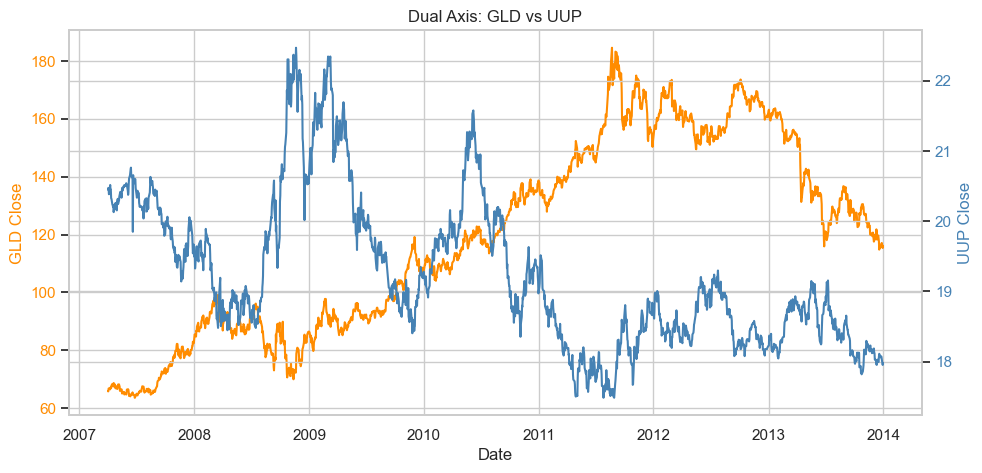

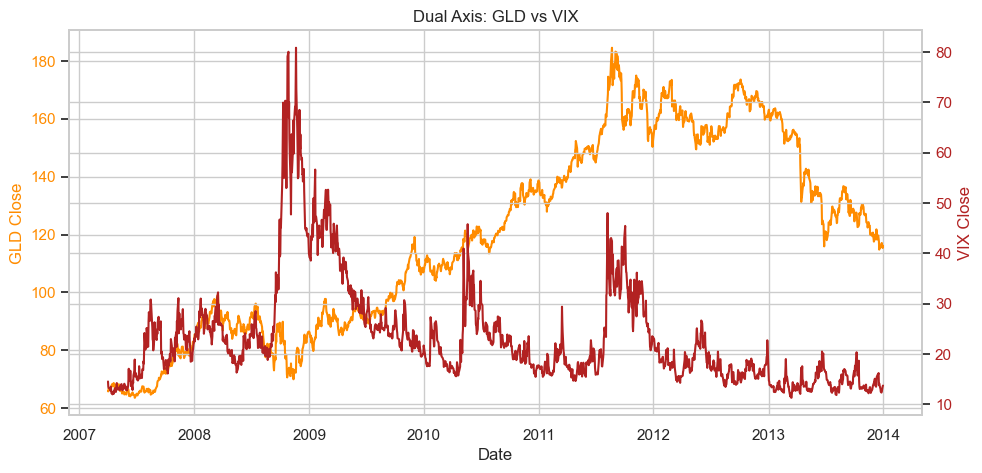

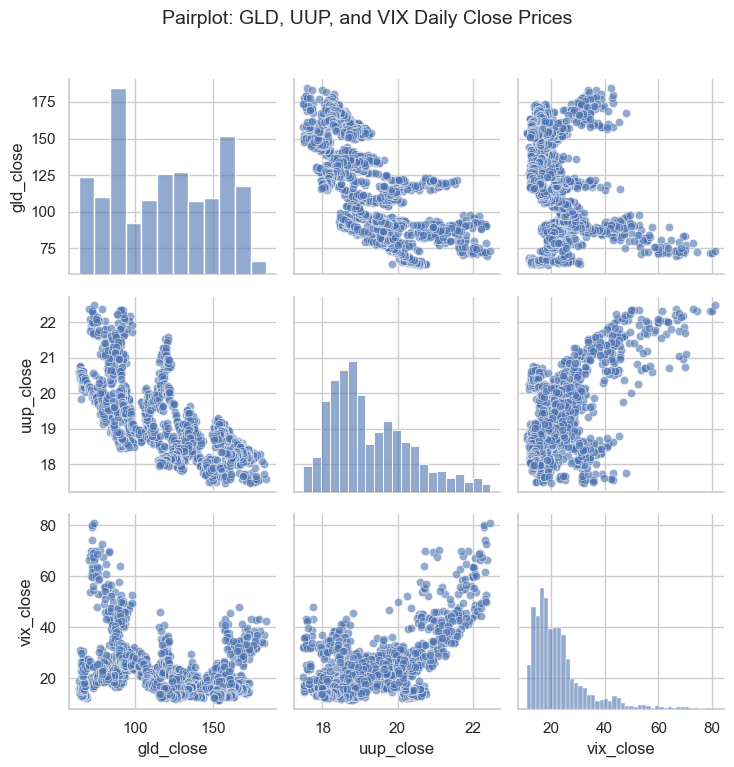

In [21]:
# Restrict index EDA to train period only
train_month_set = set(train_months)
market_train_daily = market_daily[market_daily['date'].dt.to_period('M').dt.to_timestamp().isin(train_month_set)].copy()

eda_df = market_train_daily.copy().set_index('date')

# Calculate correlations and p-values
# GLD vs UUP correlation
gld_uup_corr, gld_uup_pvalue = stats.pearsonr(eda_df['gld_close'], eda_df['uup_close'])
# GLD vs VIX correlation
gld_vix_corr, gld_vix_pvalue = stats.pearsonr(eda_df['gld_close'], eda_df['vix_close'])

print("="*60)
print("CORRELATION ANALYSIS (Training Period Only)")
print("="*60)
print(f"GLD vs UUP:")
print(f"  Correlation coefficient: {gld_uup_corr:.4f}")
print(f"  P-value: {gld_uup_pvalue:.4e}")
print(f"  {'✅ Statistically significant' if gld_uup_pvalue < 0.05 else '❌ Not statistically significant'} (p < 0.05)")
print()
print(f"GLD vs VIX:")
print(f"  Correlation coefficient: {gld_vix_corr:.4f}")
print(f"  P-value: {gld_vix_pvalue:.4e}")
print(f"  {'✅ Statistically significant' if gld_vix_pvalue < 0.05 else '❌ Not statistically significant'} (p < 0.05)")
print("="*60)

# Plot 1: GLD vs UUP (dual axis)
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(eda_df.index, eda_df['gld_close'], color='darkorange')
ax1.set_ylabel('GLD Close', color='darkorange')
ax1.tick_params(axis='y', labelcolor='darkorange')

ax2 = ax1.twinx()
ax2.plot(eda_df.index, eda_df['uup_close'], color='steelblue')
ax2.set_ylabel('UUP Close', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Dual Axis: GLD vs UUP')
ax1.set_xlabel('Date')
plt.show()

# Plot 2: GLD vs VIX (dual axis)
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(eda_df.index, eda_df['gld_close'], color='darkorange')
ax1.set_ylabel('GLD Close', color='darkorange')
ax1.tick_params(axis='y', labelcolor='darkorange')

ax2 = ax1.twinx()
ax2.plot(eda_df.index, eda_df['vix_close'], color='firebrick')
ax2.set_ylabel('VIX Close', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

ax1.set_title('Dual Axis: GLD vs VIX')
ax1.set_xlabel('Date')
plt.show()

# Plot 3: Pairplot of GLD, UUP, and VIX
pairplot_df = market_train_daily[['gld_close', 'uup_close', 'vix_close']].copy()

pairplot = sns.pairplot(pairplot_df,
                        diag_kind='hist',
                        plot_kws={'alpha': 0.6},
                        diag_kws={'alpha': 0.6})

plt.suptitle('Pairplot: GLD, UUP, and VIX Daily Close Prices',
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


From the graphs we see that there exists a negative correlation between GLD and UUP, GLD and VIX. VIX and UUP seems positively correlated。We will use UUP and VIX as two index variables to set up a model predicting gold price rise/fall.

### 4.2. Index EDA: Rolling Correlation

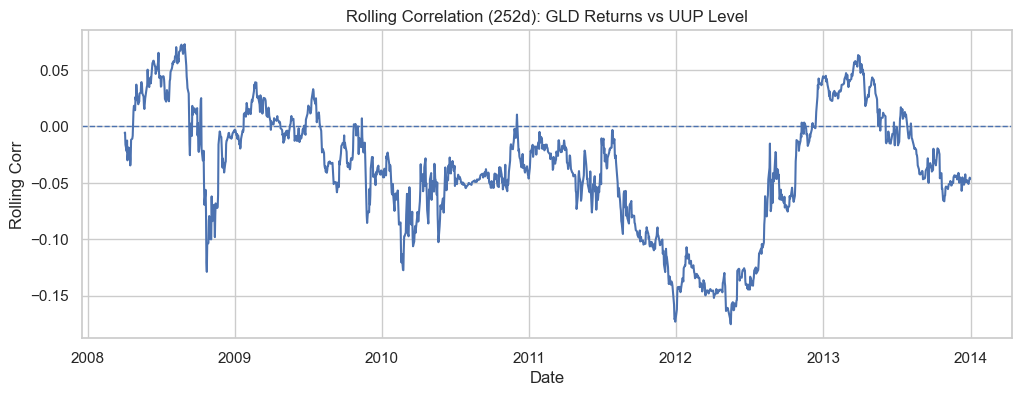

In [22]:
eda_df['gld_ret'] = eda_df['gld_close'].pct_change()
eda_df['rolling_corr_gld_uup'] = eda_df['gld_ret'].rolling(window=252).corr(eda_df['uup_close'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eda_df.index, eda_df['rolling_corr_gld_uup'])
ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('Rolling Correlation (252d): GLD Returns vs UUP Level')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Corr')
plt.show()

### 4.3. Text EDA: Word Cloud for Train Set

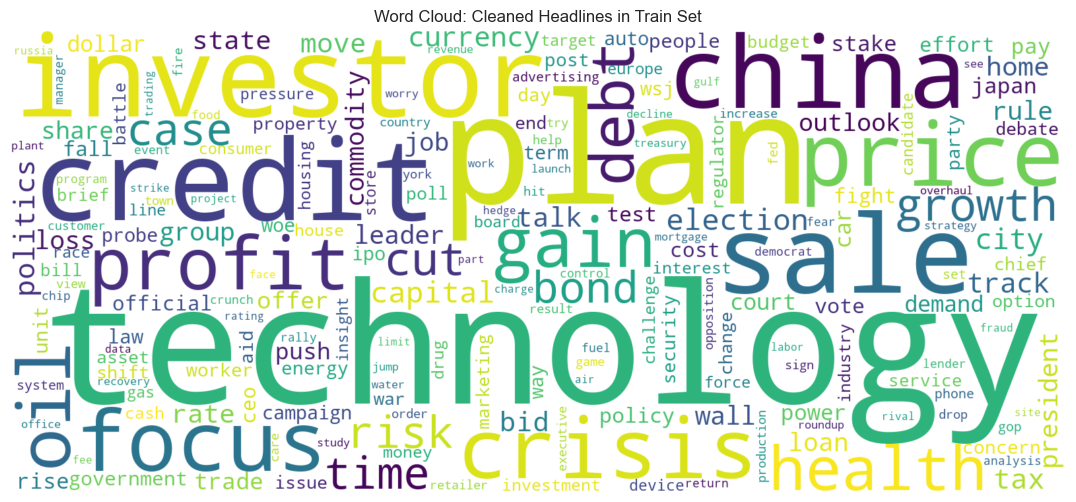

In [23]:
train_month_set = set(train_months)
head_train = news[news['month_date'].isin(train_month_set)].copy()

train_text = ' '.join(head_train['headline_clean'].astype(str))
wc_train = WordCloud(width=1600, height=700, background_color='white', collocations=False).generate(
    train_text if train_text.strip() else 'no_token'
)

plt.figure(figsize=(14, 6))
plt.imshow(wc_train, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Cleaned Headlines in Train Set')
plt.show()

### 4.4 Groupby explorations and aggregate output

In [24]:
# Groupby 1: Yearly average prices (train period only)
market_train_daily['year'] = pd.to_datetime(market_train_daily['date']).dt.year
yearly_avg = market_train_daily.groupby('year')[['gld_close', 'uup_close', 'vix_close']].mean().round(2)
print("Groupby 1: Yearly Average Prices")
print(yearly_avg)

Groupby 1: Yearly Average Prices
      gld_close  uup_close  vix_close
year                                 
2007      70.53      20.11      19.13
2008      85.98      19.73      32.69
2009      95.64      20.11      31.48
2010     120.07      19.78      22.55
2011     153.19      18.20      24.20
2012     161.97      18.57      17.80
2013     136.17      18.44      14.23


In [25]:
# Groupby 2: filter news headlines with length under 50 bytes (train period only)
news_train = news[news['month_date'].isin(set(train_months))].copy()
news_train['headline_length'] = news_train['headline'].str.len()

print()
print(f"Quartiles of headline length: {news_train['headline_length'].describe(percentiles=[.25, .5, .75]).round(2)}")

news_train['length_category'] = news_train['headline_length'].apply(
    lambda x: 'under_50_bytes' if x < 50 else 'over_50_bytes'
)

length_stats = news_train.groupby('length_category').size().reset_index(name='count')
print("\nGroupby 2: Headlines by Length Category")
print(length_stats)
print(f"\nPercentage under 50 bytes: {(length_stats[length_stats['length_category']=='under_50_bytes']['count'].values[0] / len(news_train) * 100):.2f}%")


Quartiles of headline length: count    2023.00
mean       94.55
std        36.13
min        13.00
25%        62.00
50%        90.00
75%       119.50
max       213.00
Name: headline_length, dtype: float64

Groupby 2: Headlines by Length Category
  length_category  count
0   over_50_bytes   1967
1  under_50_bytes     56

Percentage under 50 bytes: 2.77%


In [26]:
# Groupby 3: Count months where GLD close > 100 (train period only)
market_train_daily['month'] = pd.to_datetime(market_train_daily['date']).dt.to_period('M')
monthly_gld = market_train_daily.groupby('month')['gld_close'].mean().reset_index()
monthly_gld['above_100'] = monthly_gld['gld_close'] > 100

months_above_100 = monthly_gld['above_100'].sum()
total_months = len(monthly_gld)

print("Groupby 3: GLD Above $100 Analysis")
print(f"Total months analyzed: {total_months}")
print(f"Months with GLD > $100: {months_above_100}")
print(f"Percentage: {(months_above_100/total_months*100):.2f}%")

Groupby 3: GLD Above $100 Analysis
Total months analyzed: 81
Months with GLD > $100: 51
Percentage: 62.96%


### 4.5 Apply: mark headlines directly mentioning gold

In [27]:
news_apply = news[news['month_date'].isin(set(train_months))].copy()

news_apply['gold_mentioned'] = news_apply['headline'].apply(
    lambda x: bool(re.search(r'\bgold\b', str(x), re.IGNORECASE))
)

# Show results
print("Apply Example: Gold Mention in Headlines")
print(news_apply['gold_mentioned'].value_counts())
print()
print(f"Headlines mentioning gold: example\n{news_apply[news_apply['gold_mentioned'] == True][['headline','gold_mentioned']].head()}")

Apply Example: Gold Mention in Headlines
gold_mentioned
False    2012
True       11
Name: count, dtype: int64

Headlines mentioning gold: example
                                                                                                                                                                          headline  \
217                                                                                       Commodities Report Oil Surges Above a Barrel Inventory Data To Become Focus Gold Touches   
317                                                                          Fund Track Bug Control Gold Skeptics Use ETNs Notes Offer Ability To Go Short Take Leveraged Position   
889                                                                        Commodities Report Gold Grabs Headlines Not Gains Metal Flat Despite Soros Filing Bullish Demand Report   
949                                                 Barrick s Profit Soars on Gold Pricing Canadian Miner Benefits as Metal Ne

## 5. Model A: Index-Only Logistic Regression

### 5.1. Build Model A Dataset (UUP + VIX)

In [28]:
model_a_df = target_df[['month_date', 'target_up', 'uup_ret_m', 'vix_ret_m']].dropna().copy()

train_a = model_a_df[model_a_df['month_date'].isin(set(train_months))].copy()
val_a = model_a_df[model_a_df['month_date'].isin(set(val_months))].copy()
test_a = model_a_df[model_a_df['month_date'].isin(set(test_months))].copy()

x_cols_a = ['uup_ret_m', 'vix_ret_m']

X_train_a = train_a[x_cols_a].to_numpy()
y_train_a = train_a['target_up'].to_numpy()
X_val_a = val_a[x_cols_a].to_numpy()
y_val_a = val_a['target_up'].to_numpy()
X_test_a = test_a[x_cols_a].to_numpy()
y_test_a = test_a['target_up'].to_numpy()

print('Model A train/val/test:', X_train_a.shape, X_val_a.shape, X_test_a.shape)

Model A train/val/test: (81, 2) (24, 2) (24, 2)


### 5.2. Training and Evaluation with Logistic Regression

In [29]:
model_a = LogisticRegression(random_state=42, max_iter=1000)
model_a.fit(X_train_a, y_train_a)

val_probs = model_a.predict_proba(X_val_a)[:, 1]
test_probs = model_a.predict_proba(X_test_a)[:, 1]

thresholds = np.arange(0.3, 0.8, 0.05)

def select_threshold(y_true, y_prob, metric='f1', grid=None):
    if grid is None:
        grid = thresholds
    rows = []
    for t in grid:
        pred = (y_prob >= t).astype(int)
        rows.append({
            'threshold': float(t),
            'f1': f1_score(y_true, pred, zero_division=0),
            'mcc': matthews_corrcoef(y_true, pred),
        })
    curve = pd.DataFrame(rows)
    best_score = curve[metric].max()
    cand = curve[np.isclose(curve[metric], best_score)].copy()
    cand['dist'] = (cand['threshold'] - 0.5).abs()
    best_t = float(cand.sort_values(['dist', 'threshold']).iloc[0]['threshold'])
    return best_t, float(best_score), curve

thr_a_f1, val_f1_a, curve_a = select_threshold(y_val_a, val_probs, metric='f1')
thr_a_mcc, val_mcc_a, _ = select_threshold(y_val_a, val_probs, metric='mcc')

pred_test_a_050 = (test_probs >= 0.5).astype(int)
pred_test_a_f1 = (test_probs >= thr_a_f1).astype(int)
pred_test_a_mcc = (test_probs >= thr_a_mcc).astype(int)

def metric_row_a(y_true, y_pred, y_prob, split_name):
    return {
        'model': 'Model A (index only)',
        'split': split_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }

model_a_results = pd.DataFrame([
    metric_row_a(y_test_a, pred_test_a_050, test_probs, 'test@0.50'),
    metric_row_a(y_test_a, pred_test_a_f1, test_probs, f'test@best_f1({thr_a_f1:.2f})'),
    metric_row_a(y_test_a, pred_test_a_mcc, test_probs, f'test@best_mcc({thr_a_mcc:.2f})'),
])

print(f'Model A best threshold by val F1 : {thr_a_f1:.2f} (val_f1={val_f1_a:.4f})')
print(f'Model A best threshold by val MCC: {thr_a_mcc:.2f} (val_mcc={val_mcc_a:.4f})')
display(model_a_results)

model_a_results_for_compare = model_a_results.copy()

Model A best threshold by val F1 : 0.55 (val_f1=0.6061)
Model A best threshold by val MCC: 0.60 (val_mcc=0.3143)


,model,split,accuracy,precision,recall,f1,roc_auc,mcc
0,Model A (index only),test@0.50,0.625000,0.625,1.000000,0.769231,0.518519,0.000000
1,Model A (index only),test@best_f1(0.55),0.625000,0.625,1.000000,0.769231,0.518519,0.000000
2,Model A (index only),test@best_mcc(0.60),0.333333,0.400,0.133333,0.200000,0.518519,-0.238416


## 6. Model B: Text-Only Logistic Regression

### 6.1. LDA Pipeline on Headline-Level Text

In [174]:
N_TOPICS = 12

train_headlines = news[news['month_date'].isin(set(train_months))].copy()
all_headlines = news.copy()

vec = CountVectorizer(min_df=3, max_df=0.9)
X_train_head = vec.fit_transform(train_headlines['headline_clean'])
X_all_head = vec.transform(all_headlines['headline_clean'])

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method='batch',
    random_state=42,
    max_iter=30,
)
lda.fit(X_train_head)

topic_prob_all = lda.transform(X_all_head)
for k in range(N_TOPICS):
    all_headlines[f'topic_{k}'] = topic_prob_all[:, k]

# dominant topic per headline
all_headlines['topic_argmax'] = topic_prob_all.argmax(axis=1)

print('Headline-topic matrix shape:', topic_prob_all.shape)
all_headlines[['month_date','headline_clean','topic_argmax'] + [f'topic_{i}' for i in range(min(3,N_TOPICS))]].head(3)

Headline-topic matrix shape: (3245, 12)


,month_date,headline_clean,topic_argmax,topic_0,topic_1,topic_2
0,2007-03-01,focus road detroit fuel housing pressure buyer auto sale,5,0.009260,0.009259,0.009259
1,2007-03-01,focus power play expansion option enel hamper endesa,10,0.013889,0.013889,0.243190
2,2007-03-01,alltel buyer telecom equity price turn,10,0.180555,0.013889,0.013889


### 6.2. Inspect LDA Topics

In [175]:
vocab = np.array(vec.get_feature_names_out())
rows = []
topic_name_map = {}

for k, comp in enumerate(lda.components_):
    top_idx = np.argsort(comp)[-12:][::-1]
    top_terms = vocab[top_idx]
    top_words = ', '.join(top_terms)

    label_core = '_'.join(top_terms[:3])
    topic_col = f'topic_{k}'
    topic_label = f'{topic_col}_{label_core}'
    topic_name_map[topic_col] = topic_label

    rows.append({
        'topic_id': k,
        'topic_label': topic_label,
        'top_words': top_words,
        'primary_word': top_terms[0],
    })

topic_words_df = pd.DataFrame(rows)
display(topic_words_df)

,topic_id,topic_label,top_words,primary_word
0,0,topic_0_plan_day_production,"plan, day, production, chip, candidate, launch, consumer, cut, focus, rebel, airline, oil",plan
1,1,topic_1_case_property_pay,"case, property, pay, unit, tax, stake, sign, chief, election, rating, move, party",case
2,2,topic_2_trade_group_security,"trade, group, security, drug, term, lender, president, probe, system, terror, pact, age",trade
3,3,topic_3_crisis_wall_focus,"crisis, wall, focus, policy, plan, change, game, shift, line, program, election, city",crisis
4,4,topic_4_bid_cash_poll,"bid, cash, poll, marketing, fight, technology, bill, suit, end, meeting, name, battle",bid
5,5,topic_5_leader_loss_growth,"leader, loss, growth, push, wsj, com, technology, power, gop, japan, party, service",leader
6,6,topic_6_credit_investor_currency,"credit, investor, currency, dollar, oil, debt, bond, city, capital, rate, time, price",credit
7,7,topic_7_home_test_rule,"home, test, rule, ipo, technology, bond, gas, issue, outlook, plan, way, smartmoney",home
8,8,topic_8_technology_gain_share,"technology, gain, share, health, war, asset, court, phone, investor, return, price, strategy",technology
9,9,topic_9_profit_china_sale,"profit, china, sale, job, cut, outlook, track, energy, offer, growth, cost, rise",profit


### 6.3. Aggregate Topic Features to Monthly Level

In [176]:
# Mean topic probabilities per month (topic_* only)
topic_cols = [f'topic_{k}' for k in range(N_TOPICS)]
monthly_topic = all_headlines.groupby('month_date', as_index=False)[topic_cols].mean()

# Rename topic columns to readable labels
monthly_topic = monthly_topic.rename(columns=topic_name_map)

model_df = target_df.merge(monthly_topic, on='month_date', how='inner').sort_values('month_date').reset_index(drop=True)

feature_cols = [c for c in model_df.columns if c.startswith('topic_')]
print('Model monthly rows:', len(model_df))
print('Feature columns:', len(feature_cols))
print('Example feature names:', feature_cols[:6])
model_df.head(3)

Model monthly rows: 129
Feature columns: 12
Example feature names: ['topic_0_plan_day_production', 'topic_1_case_property_pay', 'topic_2_trade_group_security', 'topic_3_crisis_wall_focus', 'topic_4_bid_cash_poll', 'topic_5_leader_loss_growth']


,month_date,gld_close,target_up,uup_ret_m,vix_ret_m,topic_0_plan_day_production,topic_1_case_property_pay,topic_2_trade_group_security,topic_3_crisis_wall_focus,topic_4_bid_cash_poll,topic_5_leader_loss_growth,topic_6_credit_investor_currency,topic_7_home_test_rule,topic_8_technology_gain_share,topic_9_profit_china_sale,topic_10_risk_option_demand,topic_11_talk_fall_people
0,2007-04-01,65.849998,1,-0.004806,-0.081542,0.022027,0.085103,0.126186,0.072903,0.100396,0.109088,0.065360,0.109578,0.052027,0.157932,0.034041,0.065360
1,2007-05-01,66.690002,0,-0.008451,-0.070200,0.050378,0.090376,0.020378,0.066432,0.103680,0.115281,0.072664,0.064042,0.096397,0.108957,0.055294,0.156120
2,2007-06-01,66.440002,0,0.011770,-0.054034,0.058874,0.081200,0.158611,0.068544,0.129656,0.101238,0.141619,0.109050,0.058854,0.029527,0.018875,0.043954


### 6.4. Train Text Logistic Model

In [177]:
def metric_row(y_true, y_pred, y_prob, model_name, split_name):
    return {
        'model': model_name,
        'split': split_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        'mcc': matthews_corrcoef(y_true, y_pred),
    }

def infer(clf, X, threshold=0.5):
    prob = clf.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return pred, prob

feat_cols = [c for c in feature_cols if c.startswith('topic_')]

train_df = model_df[model_df['month_date'].isin(set(train_months))].copy()
val_df = model_df[model_df['month_date'].isin(set(val_months))].copy()
test_df = model_df[model_df['month_date'].isin(set(test_months))].copy()

X_train, y_train = train_df[feat_cols].values, train_df['target_up'].values
X_val, y_val = val_df[feat_cols].values, val_df['target_up'].values
X_test, y_test = test_df[feat_cols].values, test_df['target_up'].values

clf_b = LogisticRegression(max_iter=4000, class_weight='balanced', solver='liblinear', random_state=42)
clf_b.fit(X_train, y_train)

pred_val, prob_val = infer(clf_b, X_val, threshold=0.5)
pred_test, prob_test = infer(clf_b, X_test, threshold=0.5)

base_metrics = pd.DataFrame([
    metric_row(y_val, pred_val, prob_val, 'ModelB_LDA_Logit', 'val@0.50'),
    metric_row(y_test, pred_test, prob_test, 'ModelB_LDA_Logit', 'test@0.50'),
])

display(base_metrics)

,model,split,accuracy,precision,recall,f1,roc_auc,mcc
0,ModelB_LDA_Logit,val@0.50,0.583333,0.5,0.700000,0.583333,0.585714,0.200000
1,ModelB_LDA_Logit,test@0.50,0.541667,0.7,0.466667,0.560000,0.703704,0.130931


### 6.5. Validation Threshold Tuning

In [178]:
def best_threshold(y_true, y_prob, metric='f1', grid=None):
    if grid is None:
        grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
    rows = []
    for t in grid:
        pred = (y_prob >= t).astype(int)
        rows.append({
            'threshold': float(t),
            'f1': f1_score(y_true, pred, zero_division=0),
            'mcc': matthews_corrcoef(y_true, pred),
        })
    curve = pd.DataFrame(rows)
    best_score = curve[metric].max()
    cand = curve[np.isclose(curve[metric], best_score)].copy()
    cand['dist'] = (cand['threshold'] - 0.5).abs()
    best_t = float(cand.sort_values(['dist','threshold']).iloc[0]['threshold'])
    return best_t, float(best_score), curve

thr_b_f1, val_f1_b, curve_b_f1 = best_threshold(y_val, prob_val, metric='f1')
thr_b_mcc, val_mcc_b, curve_b_mcc = best_threshold(y_val, prob_val, metric='mcc')

pred_test_b_050, _ = infer(clf_b, X_test, threshold=0.5)
pred_test_b_f1, _ = infer(clf_b, X_test, threshold=thr_b_f1)
pred_test_b_mcc, _ = infer(clf_b, X_test, threshold=thr_b_mcc)

majority_class = int(pd.Series(y_train).mode().iloc[0])
baseline_pred = np.full(len(y_test), majority_class)
baseline_prob = np.full(len(y_test), float(majority_class))

results_b = pd.DataFrame([
    metric_row(y_test, pred_test_b_050, prob_test, 'Model B (text only)', 'test@0.50'),
    metric_row(y_test, pred_test_b_f1, prob_test, 'Model B (text only)', f'test@best_f1({thr_b_f1:.2f})'),
    metric_row(y_test, pred_test_b_mcc, prob_test, 'Model B (text only)', f'test@best_mcc({thr_b_mcc:.2f})'),
    metric_row(y_test, baseline_pred, baseline_prob, 'Baseline_MajorityClass', f'test@always_{majority_class}'),
])

print('Model B best threshold by val F1 :', round(thr_b_f1,2), 'val_f1=', round(val_f1_b,4))
print('Model B best threshold by val MCC:', round(thr_b_mcc,2), 'val_mcc=', round(val_mcc_b,4))
display(results_b)
print('Confusion matrix @ Model B best-MCC threshold')
print(confusion_matrix(y_test, pred_test_b_mcc))

model_b_results_for_compare = results_b[results_b['model'] == 'Model B (text only)'].copy()


Model B best threshold by val F1 : 0.49 val_f1= 0.5882
Model B best threshold by val MCC: 0.5 val_mcc= 0.2


,model,split,accuracy,precision,recall,f1,roc_auc,mcc
0,Model B (text only),test@0.50,0.541667,0.700,0.466667,0.560000,0.703704,0.130931
1,Model B (text only),test@best_f1(0.49),0.625000,0.625,1.000000,0.769231,0.703704,0.000000
2,Model B (text only),test@best_mcc(0.50),0.541667,0.700,0.466667,0.560000,0.703704,0.130931
3,Baseline_MajorityClass,test@always_1,0.625000,0.625,1.000000,0.769231,0.500000,0.000000


Confusion matrix @ Model B best-MCC threshold
[[6 3]
 [8 7]]


### 6.6. Coefficient Interpretation

,feature,coef,topic_name
0,topic_6_credit_investor_currency,0.381375,credit
1,topic_3_crisis_wall_focus,0.105392,crisis
2,topic_10_risk_option_demand,0.090108,risk
3,topic_0_plan_day_production,0.078533,plan
4,topic_7_home_test_rule,-0.021984,home
5,topic_8_technology_gain_share,-0.040678,technology
6,topic_2_trade_group_security,-0.045117,trade
7,topic_9_profit_china_sale,-0.045291,profit
8,topic_4_bid_cash_poll,-0.052327,bid
9,topic_1_case_property_pay,-0.095348,case


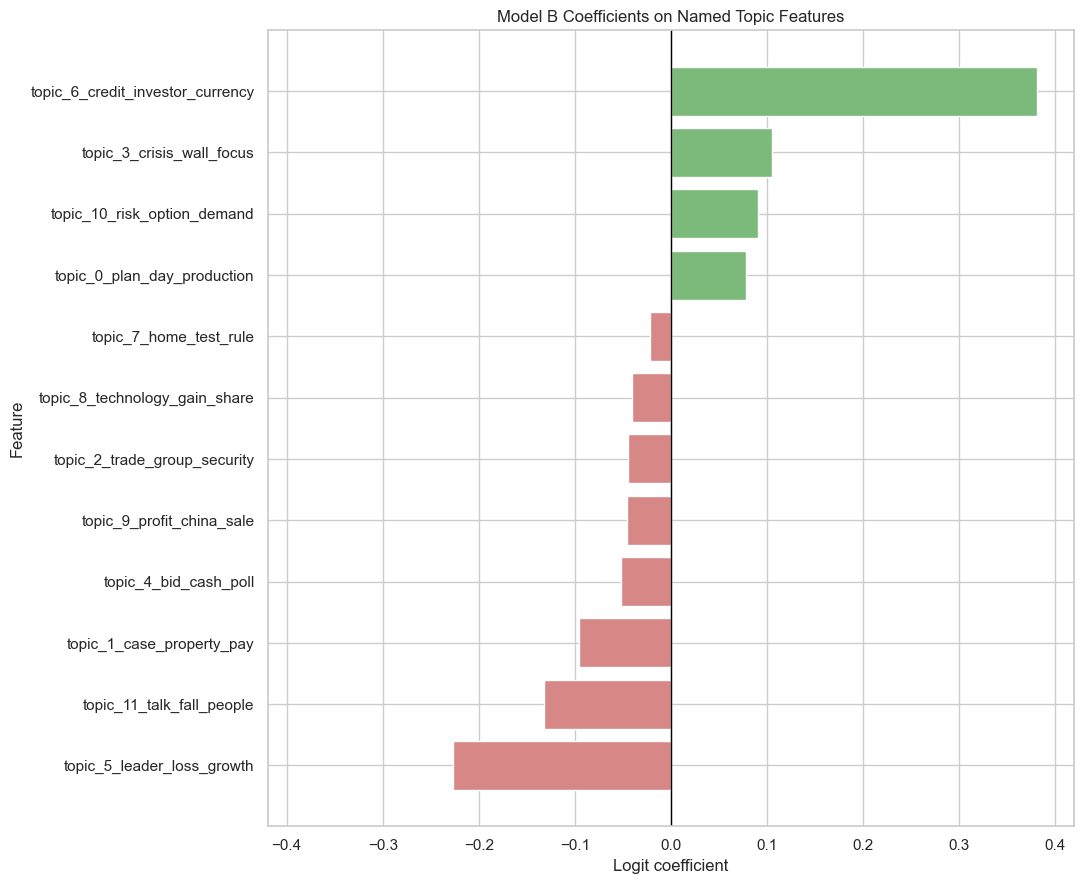

In [179]:
coef_df = pd.DataFrame({'feature': feat_cols, 'coef': clf_b.coef_.ravel()}).sort_values('coef', ascending=False).reset_index(drop=True)

def short_name(f):
    parts = f.split('_')
    if f.startswith('topic_') and len(parts) >= 3:
        return parts[2]
    return f

coef_df['topic_name'] = coef_df['feature'].map(short_name)
display(coef_df)

fig, ax = plt.subplots(figsize=(11, 9))
colors = np.where(coef_df['coef'] >= 0, "#7bba7b", "#d88787")
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
m = float(np.max(np.abs(coef_df['coef']))) if len(coef_df) else 1.0
ax.set_xlim(-1.1*m, 1.1*m)
ax.set_title('Model B Coefficients on Named Topic Features')
ax.set_xlabel('Logit coefficient')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

,feature,coef,topic_name
0,topic_6_credit_investor_currency,0.381375,credit
1,topic_3_crisis_wall_focus,0.105392,crisis
2,topic_10_risk_option_demand,0.090108,risk
3,topic_0_plan_day_production,0.078533,plan
4,topic_7_home_test_rule,-0.021984,home
5,topic_8_technology_gain_share,-0.040678,technology
6,topic_2_trade_group_security,-0.045117,trade
7,topic_9_profit_china_sale,-0.045291,profit
8,topic_4_bid_cash_poll,-0.052327,bid
9,topic_1_case_property_pay,-0.095348,case


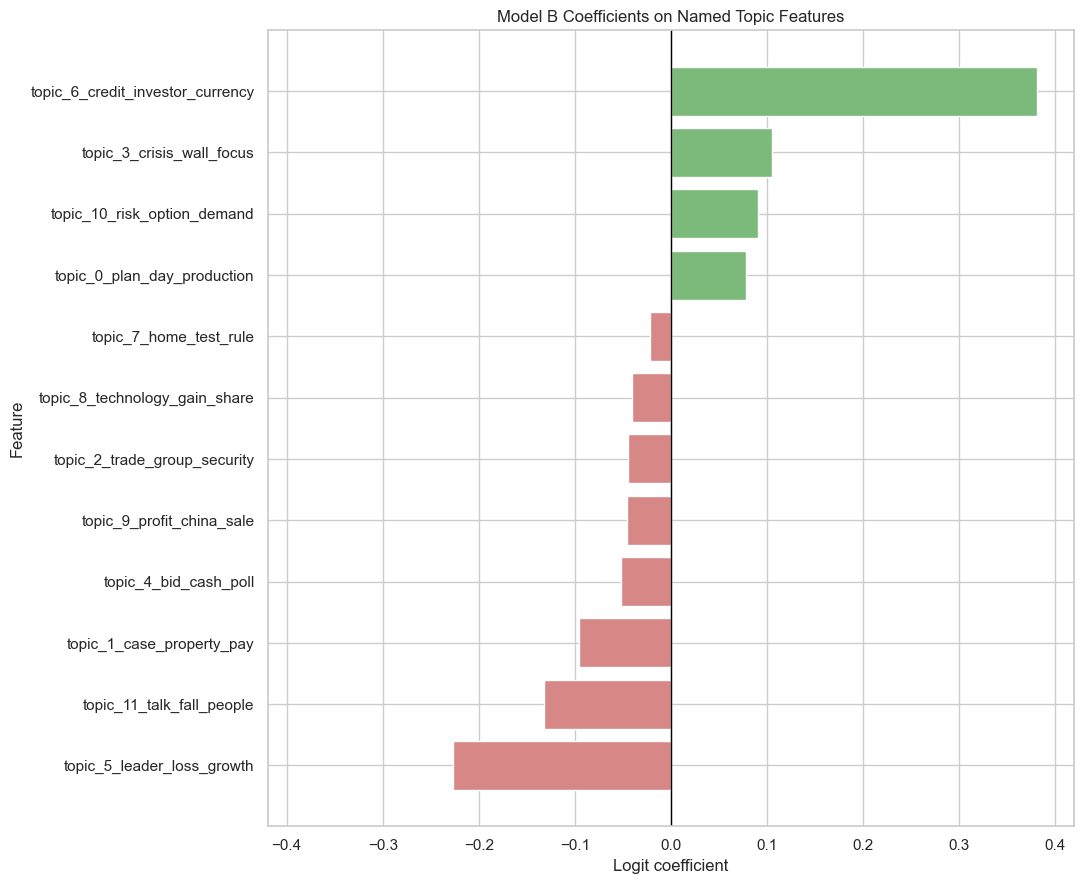

In [180]:
coef_df = pd.DataFrame({'feature': feat_cols, 'coef': clf_b.coef_.ravel()}).sort_values('coef', ascending=False).reset_index(drop=True)

def short_name(f):
    parts = f.split('_')
    if f.startswith('topic_') and len(parts) >= 3:
        return parts[2]
    return f

coef_df['topic_name'] = coef_df['feature'].map(short_name)
display(coef_df)

fig, ax = plt.subplots(figsize=(11, 9))
colors = np.where(coef_df['coef'] >= 0, "#7bba7b", "#d88787")
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
m = float(np.max(np.abs(coef_df['coef']))) if len(coef_df) else 1.0
ax.set_xlim(-1.1*m, 1.1*m)
ax.set_title('Model B Coefficients on Named Topic Features')
ax.set_xlabel('Logit coefficient')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Model Comparison and Investor Insight

### 7.1. Side-by-Side Comparison Table

In [181]:
comparison_df = pd.concat([
    model_a_results_for_compare,
    model_b_results_for_compare
], ignore_index=True)

comparison_df = comparison_df[[
    'model','split','accuracy','precision','recall','f1','roc_auc','mcc'
]].sort_values(['model','split']).reset_index(drop=True)

print('Model comparison under different validation-threshold criteria (F1 vs MCC):')
display(comparison_df)


Model comparison under different validation-threshold criteria (F1 vs MCC):


,model,split,accuracy,precision,recall,f1,roc_auc,mcc
0,Model A (index only),test@0.50,0.625000,0.625,1.000000,0.769231,0.518519,0.000000
1,Model A (index only),test@best_f1(0.55),0.625000,0.625,1.000000,0.769231,0.518519,0.000000
2,Model A (index only),test@best_mcc(0.60),0.333333,0.400,0.133333,0.200000,0.518519,-0.238416
3,Model B (text only),test@0.50,0.541667,0.700,0.466667,0.560000,0.703704,0.130931
4,Model B (text only),test@best_f1(0.49),0.625000,0.625,1.000000,0.769231,0.703704,0.000000
5,Model B (text only),test@best_mcc(0.50),0.541667,0.700,0.466667,0.560000,0.703704,0.130931


### 7.2 Plot

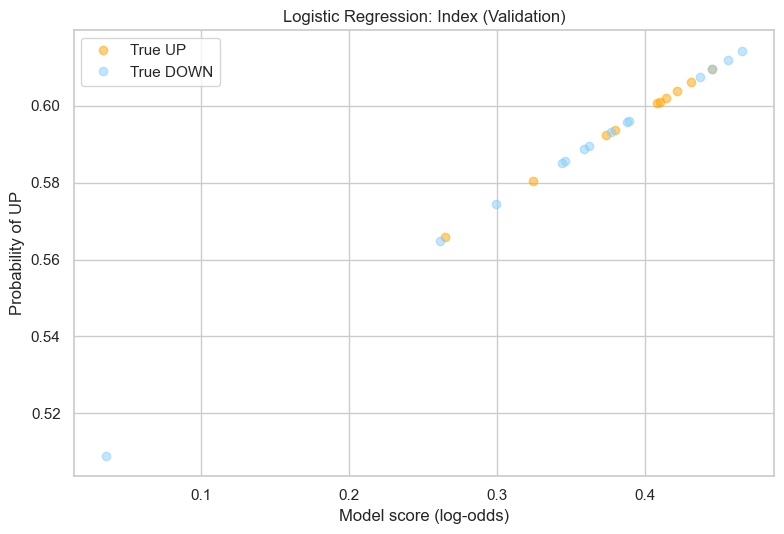

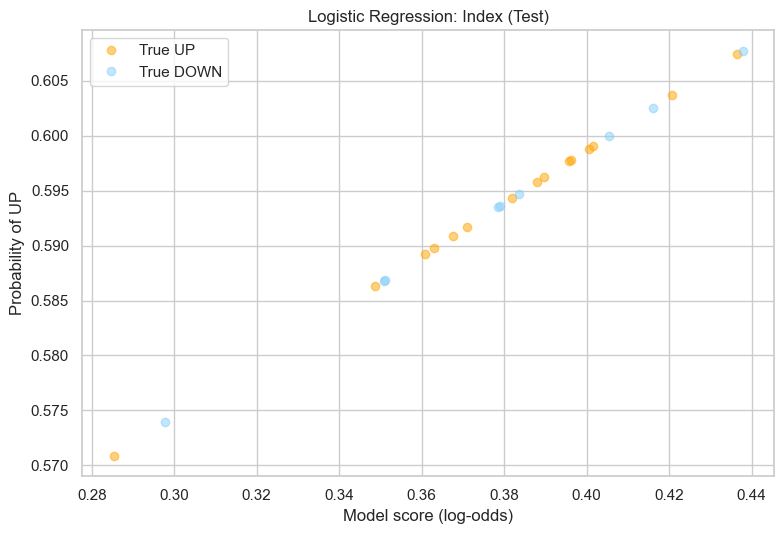

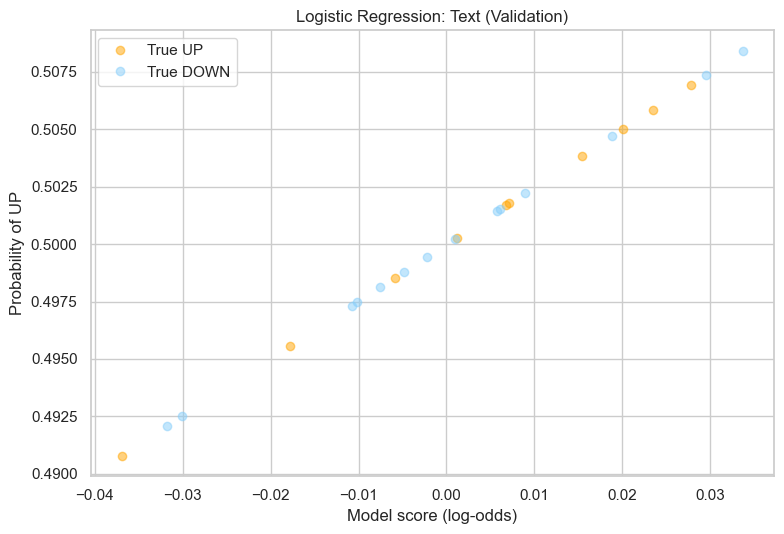

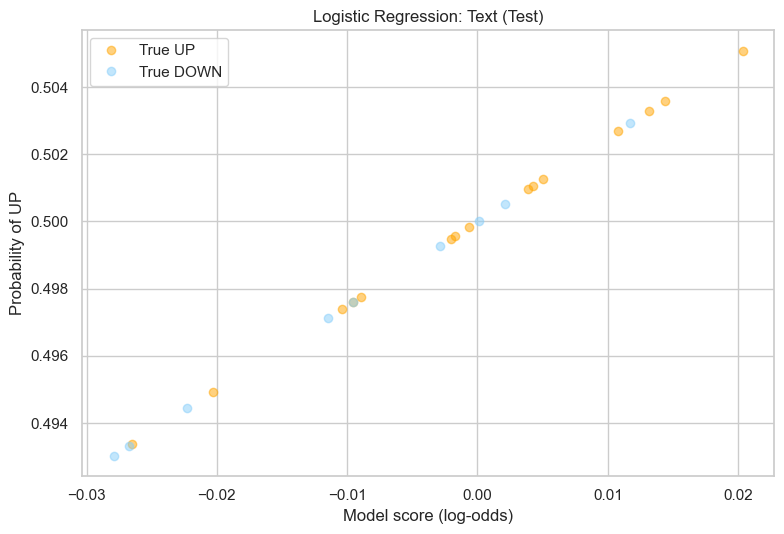

In [182]:
UP_COLOR = 'orange'       # True UP
DOWN_COLOR = 'lightskyblue'  # True DOWN


def plot_simple(score_input, prob_prediction, up_mask, title, out_path):
    plt.figure(figsize=(8, 5.5))
    plt.plot(score_input[up_mask], prob_prediction[up_mask], 'o', color=UP_COLOR, label='True UP', alpha=0.5)
    plt.plot(score_input[~up_mask], prob_prediction[~up_mask], 'o', color=DOWN_COLOR, label='True DOWN', alpha=0.5)
    plt.xlabel('Model score (log-odds)')
    plt.ylabel('Probability of UP')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.show()


# 1) Index - Validation
score_idx_val = model_a.decision_function(X_val_a)
prob_idx_val = model_a.predict_proba(X_val_a)[:, 1]
up_idx_val = (y_val_a == 1)
plot_simple(score_idx_val, prob_idx_val, up_idx_val,
            'Logistic Regression: Index (Validation)',
            'slides_assets/fig_index_validation_simple.png')

# 2) Index - Test
score_idx_test = model_a.decision_function(X_test_a)
prob_idx_test = model_a.predict_proba(X_test_a)[:, 1]
up_idx_test = (y_test_a == 1)
plot_simple(score_idx_test, prob_idx_test, up_idx_test,
            'Logistic Regression: Index (Test)',
            'slides_assets/fig_index_test_simple.png')

# 3) Text - Validation
score_txt_val = clf_b.decision_function(X_val)
prob_txt_val = clf_b.predict_proba(X_val)[:, 1]
up_txt_val = (y_val == 1)
plot_simple(score_txt_val, prob_txt_val, up_txt_val,
            'Logistic Regression: Text (Validation)',
            'slides_assets/fig_text_validation_simple.png')

# 4) Text - Test
score_txt_test = clf_b.decision_function(X_test)
prob_txt_test = clf_b.predict_proba(X_test)[:, 1]
up_txt_test = (y_test == 1)
plot_simple(score_txt_test, prob_txt_test, up_txt_test,
            'Logistic Regression: Text (Test)',
            'slides_assets/fig_text_test_simple.png')

### 7.3. Interpretation

#### Conclusion
For our final evaluation criterion, we prioritize MCC (Matthews Correlation Coefficient) because it integrates all four confusion-matrix components (TP, TN, FP, FN) and therefore best matches our economic objective: correctly distinguishing up vs. down directions, rather than exploiting class imbalance.

Under the MCC-based threshold selection, the conclusion is clear: Text (Model B) is more reliable than Index (Model A) in this sample and test window. In test, Model A's MCC is negative (about -0.238), while Model B's MCC is positive (about +0.131). This suggests the index-only signal is unstable out-of-sample in this period, while text topics still retain some directional discrimination power. A plausible reason is that gold-index relations are regime-dependent, and two index features (UUP, VIX) may not fully capture shifting macro narratives that are partially reflected in news text.

At the same time, we also note that if we select thresholds by F1 (economically interpreted as "do not miss upside opportunities"), the picture looks different:
In test, our Model A (UUP+VIX index-only regression) has achieved higher accuracy (62.5%), but its perfect recall (1.0) indicates the model predicts all samples as "up", its MCC = 0.0 also suggests it has zero predictive power (equivalent to random guessing), probably because gold price was generally growing. Model B has lower accuracy (54.17%) but demonstrates actual learning. It has higher precision (70%) but at the cost of low recall (46.67%). Both models have problems, but their comparison suggests that some advantages in each prediction method and some potential problems to watch out for. Among them is gaming -- when the model exploits class imbalance by predicting the majority class for all samples.

#### Future Improvements
Several enhancements could strengthen this analysis. First, extend the time horizon to include more complete market cycles, ensuring the model is tested across more bullish and bearish periods for gold. Second, account for trend persistence by adding lag features and richer macro factors. Third, improve text robustness with more advanced embeddings and stricter out-of-sample validation protocols.
